In [1]:
!pip install pycaret

In [2]:
import pandas as pd
from pycaret.classification import *

In [3]:
data = pd.read_csv("emergency_traige.csv", sep=";", encoding="ISO-8859-1")
data

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,2,2,79,5,2,1,mental change,1,0,#BOÞ!,...,36.4,95,2,Cerebral infarction due to unspecified occlusi...,2,2,0,1995,"3,00",0
1263,2,2,81,2,3,1,dysuria,1,0,#BOÞ!,...,36.4,97,4,Dysuria,1,4,0,1000,"2,00",0
1264,2,2,81,17,2,1,dizziness,1,0,#BOÞ!,...,36.2,99,3,Dizziness and giddiness,1,3,0,310,"4,00",0
1265,2,1,81,2,2,2,"Sensory, Decreased",1,0,#BOÞ!,...,36.6,98,3,"Cord compression, unspecified",7,3,0,475,"5,00",0


In [4]:
env_setup = setup(data=data, target='KTAS_expert', session_id=123, fold=5)

,Description,Value
0,Session id,123
1,Target,KTAS_expert
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3, 5: 4"
4,Original data shape,"(1267, 24)"
5,Transformed data shape,"(1267, 62)"
6,Transformed train set shape,"(886, 62)"
7,Transformed test set shape,"(381, 62)"
8,Numeric features,13
9,Categorical features,10


In [5]:
data["KTAS_expert"].value_counts()

KTAS_expert
3    487
4    459
2    220
5     75
1     26
Name: count, dtype: int64

In [6]:
best_model = compare_models(sort="AUC")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8803,0.9815,0.8803,0.8872,0.8740,0.8206,0.8259,0.8080
et,Extra Trees Classifier,0.8442,0.9789,0.8442,0.8514,0.8289,0.7646,0.7707,0.0980
rf,Random Forest Classifier,0.8025,0.9698,0.8025,0.8076,0.7780,0.6987,0.7099,0.1020
dt,Decision Tree Classifier,0.9514,0.9643,0.9514,0.9528,0.9506,0.9291,0.9299,0.5600
nb,Naive Bayes,0.1332,0.5771,0.1332,0.2566,0.1066,0.0031,0.0047,0.6840
knn,K Neighbors Classifier,0.3814,0.5737,0.3814,0.3516,0.3635,0.0644,0.0652,0.6580
dummy,Dummy Classifier,0.3849,0.5000,0.3849,0.1481,0.2139,0.0000,0.0000,0.0460
lr,Logistic Regression,0.4492,0.0000,0.4492,0.3797,0.3878,0.1239,0.1340,0.9180
svm,SVM - Linear Kernel,0.3736,0.0000,0.3736,0.1655,0.2098,0.0002,-0.0165,0.0620
ridge,Ridge Classifier,0.7054,0.0000,0.7054,0.6674,0.6778,0.5511,0.5587,0.0500


In [20]:
model_decision_tree_classifier = create_model("dt")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9775,0.9821,0.9775,0.9777,0.9775,0.9674,0.9674
1,0.9605,0.9699,0.9605,0.9617,0.9596,0.9419,0.9428
2,0.9548,0.9658,0.9548,0.9552,0.9544,0.9338,0.9338
3,0.9548,0.9668,0.9548,0.9579,0.9543,0.9340,0.9350
4,0.9096,0.9367,0.9096,0.9114,0.9070,0.8686,0.8702
Mean,0.9514,0.9643,0.9514,0.9528,0.9506,0.9291,0.9299
Std,0.0225,0.0150,0.0225,0.0221,0.0234,0.0327,0.0322


In [21]:
print(model_decision_tree_classifier)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')


In [22]:
tune_decision_tree_classifier = tune_model(model_decision_tree_classifier)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9775,0.9821,0.9775,0.9777,0.9775,0.9674,0.9674
1,0.9661,0.9847,0.9661,0.9678,0.9653,0.9502,0.9510
2,0.9492,0.9664,0.9492,0.9502,0.9467,0.9254,0.9255
3,0.9548,0.9748,0.9548,0.9579,0.9502,0.9339,0.9350
4,0.9548,0.9824,0.9548,0.9555,0.9550,0.9343,0.9344
Mean,0.9605,0.9781,0.9605,0.9618,0.9589,0.9422,0.9427
Std,0.0101,0.0067,0.0101,0.0098,0.0112,0.0149,0.0148


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [23]:
print(tune_decision_tree_classifier)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=6, max_features=1.0, max_leaf_nodes=None,
                       min_impurity_decrease=0.002, min_samples_leaf=5,
                       min_samples_split=5, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')


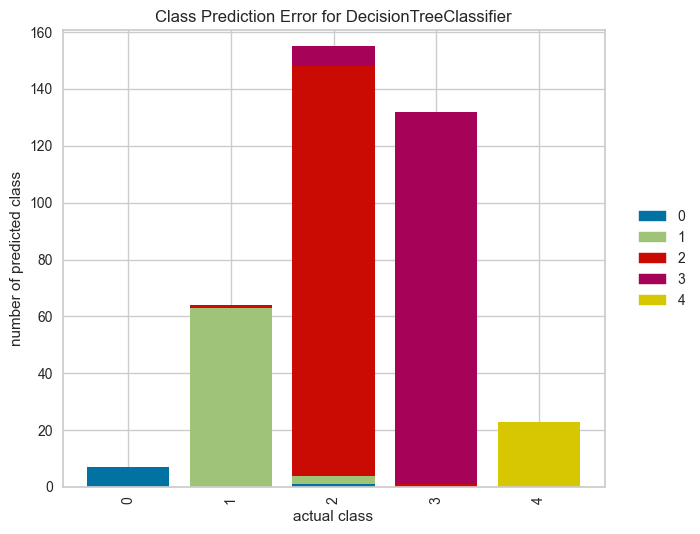

In [24]:
plot_model(tune_decision_tree_classifier, plot='error')

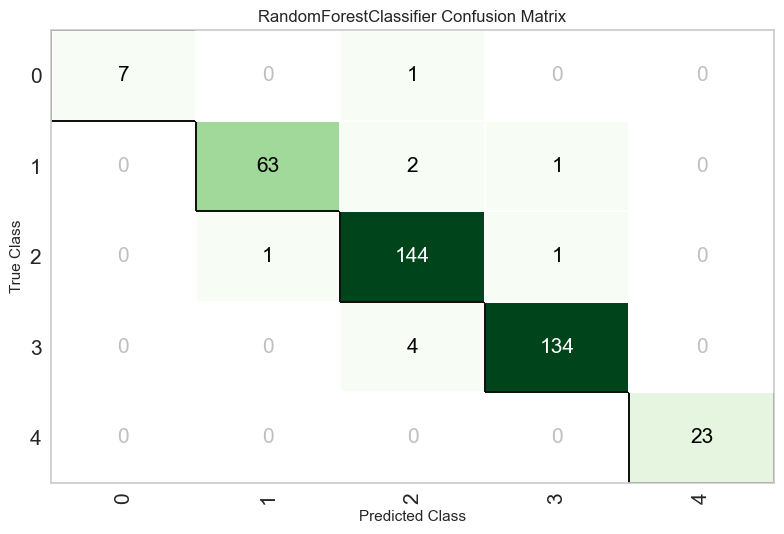

In [12]:
plot_model(tune_ridge_classifier , plot='confusion_matrix')

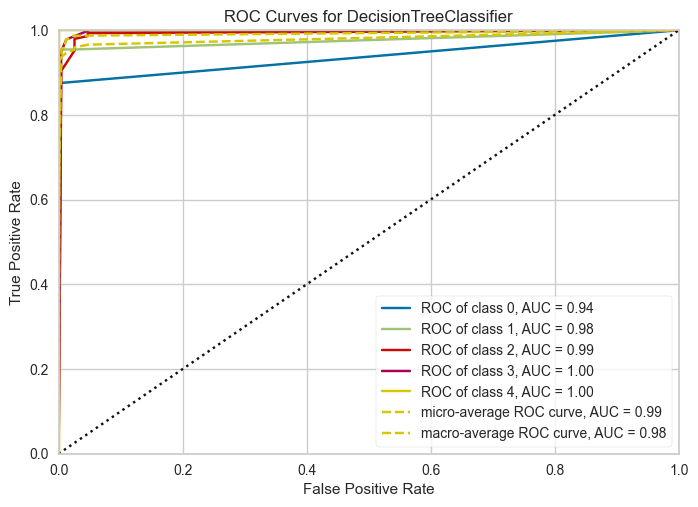

In [25]:
plot_model(tune_decision_tree_classifier , plot='auc')

In [26]:
save_model(tune_decision_tree_classifier,'emergency_traige_pycaret_dt_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Group', 'Sex', 'Age',
                                              'Patients number per hour',
                                              'Arrival mode', 'Injury', 'Mental',
                                              'Pain', 'KTAS_RN', 'Disposition',
                                              'Error_group',
                                              'Length of stay_min',...
                                     transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                 ('trained_model',
                  DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                              